# **MediCare Patient Follow-Up Agent**

In [ ]:
! pip install pandas langchain langchain_core langchain_groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.4 MB/s eta 0:00:00


# **Task 1 — Data Loading & Exploratory Analysis**

In [ ]:
import pandas as pd

# Load patient dataset
df = pd.read_csv("patient_data.csv")

# Display the first 5 patient records
print("Top 5 Patient Records:")
df.head()

Top 5 Patient Records:


,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,4/24/2024,6/8/2024,251,No,174,70,95,96,Patient reports good medication adherence.
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,1/14/2024,2/28/2024,352,No,174,91,72,97,Patient reports no new symptoms.
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,8/4/2024,10/3/2024,149,No,132,86,64,91,Medication dose adjusted this visit.
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,1/23/2024,4/22/2024,343,No,153,70,93,94,Patient reports no new symptoms.
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,4/26/2024,6/25/2024,249,No,134,71,82,94,Patient education provided on diet and lifestyle.


In [4]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 100 rows × 18 columns


In [5]:
print("Patient Dataset Information:")
df.info()

Patient Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               100 non-null    object 
 1   patient_name             100 non-null    object 
 2   age                      100 non-null    int64  
 3   gender                   100 non-null    object 
 4   diagnosis                100 non-null    object 
 5   current_medication       100 non-null    object 
 6   lab_test                 100 non-null    object 
 7   lab_value                100 non-null    float64
 8   lab_unit                 100 non-null    object 
 9   last_visit_date          100 non-null    object 
 10  next_scheduled_visit     100 non-null    object 
 11  days_since_last_visit    100 non-null    int64  
 12  missed_last_appointment  100 non-null    object 
 13  vitals_bp_systolic       100 non-null    int64  
 14

In [6]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Duplicate Records:", df.duplicated().sum())

print("\nUnique Patient IDs:", df["patient_id"].nunique())

Missing Values in Each Column:
patient_id                 0
patient_name               0
age                        0
gender                     0
diagnosis                  0
current_medication         0
lab_test                   0
lab_value                  0
lab_unit                   0
last_visit_date            0
next_scheduled_visit       0
days_since_last_visit      0
missed_last_appointment    0
vitals_bp_systolic         0
vitals_bp_diastolic        0
vitals_heart_rate          0
vitals_spo2                0
notes                      0
dtype: int64

Total Duplicate Records: 0

Unique Patient IDs: 100


# **Task 2 — Define Agent Tools**

In [7]:
from langchain_core.tools import tool

# Tool 1: Fetch Patient Clinical Record
@tool
def get_patient_record(patient_id: str) -> dict:
    """
    Retrieve the complete clinical record for a patient using the patient ID.
    Use this tool whenever patient information is required for analysis.

    Args:
        patient_id (str): Unique patient identifier (e.g., P0001).

    Returns:
        dict: Complete patient record. Returns an error message if the patient ID is not found.
    """
    patient = df[df["patient_id"] == patient_id]

    if patient.empty:
        return {"error": f"Patient {patient_id} not found"}

    return patient.iloc[0].to_dict()


In [ ]:
# Tool 2: Analyze Patient Clinical Information
@tool
def analyze_patient_risk(patient_id: str) -> str:
    """
    Retrieve a patient's clinical record and prepare a structured summary
    for clinical risk assessment.
    Use this tool after identifying the patient to assess risk.

    Args:
        patient_id (str): Unique patient identifier (e.g., P0001).

    Returns:
        str: Structured patient clinical summary for risk assessment.
             Returns an error message if the patient ID is not found.
    """
    patient = df[df["patient_id"] == patient_id]

    if patient.empty:
        return f"Error: Patient {patient_id} not found"

    patient_data = patient.iloc[0].to_dict()

    return f"""
    Patient Information:
    Name: {patient_data['patient_name']}
    Age: {patient_data['age']}
    Gender: {patient_data['gender']}

    Diagnosis: {patient_data['diagnosis']}
    Medication: {patient_data['current_medication']}

    Lab Test: {patient_data['lab_test']} = {patient_data['lab_value']} {patient_data['lab_unit']}

    Blood Pressure: {patient_data['vitals_bp_systolic']}/{patient_data['vitals_bp_diastolic']} mmHg
    Heart Rate: {patient_data['vitals_heart_rate']} bpm
    SpO2: {patient_data['vitals_spo2']}%

    Days Since Last Visit: {patient_data['days_since_last_visit']}
    Missed Last Appointment: {patient_data['missed_last_appointment']}

    Clinical Notes: {patient_data['notes']}
    """


# **Task 3 — Implement the Agentic Loop**

In [ ]:
import os
from google.colab import userdata
from langchain_groq import ChatGroq

# Initialize Groq LLM
groq_api_key = userdata.get("GROQ_API_KEY")

llm = ChatGroq(model = "llama-3.3-70b-versatile", api_key = groq_api_key)

In [ ]:
tools = [get_patient_record, analyze_patient_risk]
llm_with_tools = llm.bind_tools(tools)

In [12]:
# Define LangGraph State
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, SystemMessage
from langgraph.graph.message import add_messages

# State schema
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# System Prompt
SYSTEM_PROMPT = """
You are an AI Healthcare Follow-up Assistant.

Your responsibilities are:
1. Retrieve patient information using the available tools.
2. Analyze the patient's clinical information.
3. Assess the patient's overall clinical risk (Low, Medium, or High).
4. Explain the reason for the assigned risk level.
5. Recommend appropriate follow-up actions.
6. Recommend appointment priority (Urgent, Routine, or Non-Urgent).
7. Always use the available tools when patient information is required.
8. Never invent patient information.
"""

# LLM Node
def tool_calling_llm(state: State):

    response = llm_with_tools.invoke([SystemMessage(content=SYSTEM_PROMPT)] + state["messages"])

    return {"messages": [response]}

✅ LangGraph Agent Compiled Successfully!


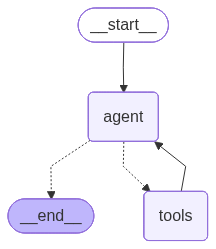

In [13]:
# Build LangGraph Agent
from IPython.display import Image, display
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition

# Create StateGraph
builder = StateGraph(State)

# Add Nodes
builder.add_node("agent", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Define Graph Flow
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

# Compile Graph
graph = builder.compile()

print("✅ LangGraph Agent Compiled Successfully!")

# Visualize Graph
display(Image(graph.get_graph().draw_mermaid_png()))

# **Task 4 — Single Patient Analysis**

In [14]:
from langchain_core.messages import HumanMessage

patient_id = "P0001"

# Invoke the LangGraph agent
result = graph.invoke({"messages": [HumanMessage(content=f"Analyze patient {patient_id}. Assess the risk level and recommend follow-up actions.")]})

# Display the final response
print("=" * 70)
print(f"Single Patient Analysis: {patient_id}")
print("=" * 70)
print(result["messages"][-1].content)

Single Patient Analysis: P0001
Based on the patient's information, I assess the risk level as High. The reason for this assessment is the patient's high HbA1c level (9.9%), which indicates poor blood sugar control. Additionally, the patient's blood pressure is elevated (174/70 mmHg), which increases the risk of cardiovascular complications.

I recommend the following follow-up actions:

1. Schedule an urgent appointment with the patient to discuss their medication regimen and potential adjustments to improve blood sugar control.
2. Order additional lab tests to monitor the patient's kidney function and liver function, as these can be affected by diabetes and high blood pressure.
3. Refer the patient to a cardiologist to evaluate their cardiovascular risk and develop a plan to manage their blood pressure.
4. Educate the patient on the importance of medication adherence, healthy diet, and regular exercise to manage their diabetes and blood pressure.

I recommend an Urgent appointment pri

# **Task 5 — Missed Appointment Follow-Up**

In [16]:
# Identify patients who missed their last appointment
missed_patients = df[df["missed_last_appointment"].str.lower() == "yes"]
print(f"Total patients who missed appointments: {len(missed_patients)}")

results = []

for pid in missed_patients["patient_id"]:
    result = graph.invoke(
        {"messages": [HumanMessage(
            content=f"Analyze patient {pid}. The patient missed their last appointment. "
                    f"Provide risk level, reason, follow-up actions, and appointment priority."
        )]}
    )
    results.append({
        "patient_id": pid,
        "recommendation": result["messages"][-1].content
    })

# Display results as DataFrame
followup_df = pd.DataFrame(results)
print(f"\nFollow-up recommendations generated for {len(followup_df)} patients")
followup_df

Total patients who missed appointments: 15

Follow-up recommendations generated for 15 patients


,patient_id,recommendation
0,P0018,"Based on the patient's clinical record, I have..."
1,P0031,"Based on the patient's record, I would assess ..."
2,P0036,"Based on the patient's record, I would assess ..."
3,P0041,"The patient, Tarun Mukherjee, has a diagnosis ..."
4,P0043,"The patient, Gaurav Dey, has a clinical risk l..."
5,P0058,"Based on the patient's clinical information, I..."
6,P0062,"Based on the patient's clinical information, I..."
7,P0063,"Based on the patient's clinical information, I..."
8,P0066,"Based on the patient's record, I would assign ..."
9,P0069,Based on the analysis of patient P0069's clini...
